# 7章 レイヤとカプセル化

ここまでに、パケットを中継するノードとしてスイッチとルータを実装しました。
それぞれ、MACアドレスとIPアドレスという異なるアドレス情報を用いてパケット転送を行うことを学びました。
さて、ではどうして異なる装置で、異なるアドレスを用いる必要があるのでしょうか。
本章では、ネットワークのレイヤすなわち階層構造について学習します。

## レイヤとアドレス

### プロトコルスタック

インターネットは非常に巨大なネットワークですが、ネットワークのネットワークとも呼ばれ、すなわち数多くのローカルネットワーク同士を接続したものです。
ネットワークそのものがある種の階層構造をとっており、対応する通信機能も階層構造をとっています。
通信プロトコルの組み合わせを階層的、すなわちレイヤ状に表現したものをプロトコルスタックと呼びます。
各レイヤがそれぞれ異なる役割を担っており、その組み合わせによって遠くのノードとの通信が実現されるのです。
このような階層構造をつくるメリットは、レイヤごとの機能がシンプル化されるため、プロトコルの設計や実装がしやすくなることです。
プロトコルスタックとしては、OSI参照モデルやTCP/IPが有名です。

### レイヤ構成

MACアドレスとIPアドレスという異なるアドレス情報を用いるのは、レイヤごとにそれぞれのアドレス情報を用いるためです。
MACアドレスはローカルネットワークでノード同士が直接通信するときに用いられます。
一方でIPアドレスは、インターネット上の遠くのノードと通信する際に主に用いられます。

IPアドレスにはネットワークアドレスによるルーティングの仕組みがあり、スケーラビリティが高いためです。
ただし一部のプライベート用のアドレスを除いて、勝手に割り振れないように管理されています。
MACアドレスは無作為にノードに割り当てられているため、スケーラビリティはないのですが、逆に管理もされていないため、近距離のノード同士であればアドレス情報を意識せずに通信できます（これまでの日常生活で、MACアドレスを意識したことはないですよね？）。

レイヤ構成で言えば、OSI参照モデルでは最下位のレイヤ1が通信媒体を表す物理層、レイヤ2がMACアドレスを用いるデータリンク層、そしてレイヤ3がIPアドレスを用いるネットワーク層です。
TCP/IPでは、通信媒体とMACアドレスによる転送機能とを合わせてネットワークインタフェース層、IPアドレスを用いるのは同じくネットワーク層と呼びます。

いずれにせよ、スイッチ等を用いるローカルネットワークではMACアドレスによって、ルータ間ではIPアドレスによってパケットが転送されます。
前章までに作ってきたクラスを少し修正し、このような実際のパケット転送を実装していきます。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [1]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 443, done.
remote: Total 443 (delta 0), reused 0 (delta 0), pack-reused 443
Receiving objects: 100% (443/443), 116.50 KiB | 840.00 KiB/s, done.
Resolving deltas: 100% (326/326), done.


### `Node`クラスのアップデート

#### MACアドレスの自動生成

これまではMACアドレスを指定して設定していましたが、MACアドレスを自動生成するようにします。
インスタンス生成時にMACアドレスが指定されない場合、`generate_mac_address`メソッドを用いてランダムなアドレスを付与します。

```
class Node:
    def __init__(self, node_id, ip_address, network_event_scheduler, mac_address=None, mtu=1500, default_route=None):
        if mac_address is None:
            self.mac_address = self.generate_mac_address()  # MACアドレスが指定されていない場合、ランダムなMACアドレスを生成
        else:
            if not self.is_valid_mac_address(mac_address):
                raise ValueError("無効なMACアドレス形式です。")  # 指定されたMACアドレスが無効な形式の場合、例外を投げる
            self.mac_address = mac_address  # 有効なMACアドレスが指定されている場合、その値を使用
        
        self.arp_table = {}  # ARPテーブルを初期化。IPアドレスとMACアドレスのマッピングを保持する辞書

    def generate_mac_address(self):
        # ランダムなMACアドレスを生成するメソッド
        # UUIDを基にして、0から12まで2ステップごとにループし、各要素を16進数の2桁の文字列に変換してコロンで連結
        return ':'.join(['{:02x}'.format(uuid.uuid4().int >> elements & 0xff) for elements in range(0, 12, 2)])
```

##### ARPテーブル

ノードは、ARPテーブルと呼ばれるテーブルを用いて、IPアドレスとそれに対応するMACアドレスをマッピングします。
これは、インターネット上でパケットを送信する際には、相手をIPアドレスで指定するためです。
ただし実際にはURL（ドメイン）で指定しますが、これはIPアドレスへと変換されるためです（次章で扱います）。
つまりユーザはMACアドレスを意識せずに通信することができ、そのために用いられるのがARPテーブルです。

- `add_to_arp_table`メソッドは、外部からこのノードのARPテーブルに新たなIPアドレスとMACアドレスのマッピングを追加するために使用されます。これにより、ネットワーク上の他のデバイスとの通信を効率化します。
- `get_mac_address_from_ip`メソッドは、指定されたIPアドレスに対応するMACアドレスを取得する際に使用されます。これは主に、パケットを送信する際に宛先デバイスのMACアドレスを特定するために必要です。
- `print_arp_table`メソッドは、デバッグやネットワーク管理の目的で、ARPテーブルの現在の内容を表示するために使用されます。これにより、ネットワーク管理者はネットワーク上のデバイス間のIPとMACアドレスのマッピングを確認できます。

```
def add_to_arp_table(self, ip_address, mac_address):
    # ARPテーブルにIPアドレスとMACアドレスのマッピングを追加するメソッド
    self.arp_table[ip_address] = mac_address  # 引数で指定されたIPアドレスとMACアドレスのペアをARPテーブルに追加

def get_mac_address_from_ip(self, ip_address):
    # 指定されたIPアドレスに対応するMACアドレスをARPテーブルから取得するメソッド
    return self.arp_table.get(ip_address, None)  # ARPテーブルからIPアドレスに対応するMACアドレスを取得。該当するエントリーがなければNoneを返す

def print_arp_table(self):
    # ARPテーブルの内容をコンソールに出力するメソッド
    print(f"ARPテーブル（ルータ {self.node_id}）:")  # ノードIDを含むARPテーブルのヘッダーを出力
    for ip_address, mac_address in self.arp_table.items():  # ARPテーブル内の全てのIPアドレスとMACアドレスのペアに対して繰り返し
        print(f"IPアドレス: {ip_address} -> MACアドレス: {mac_address}")  # 各IPアドレスとそれに対応するMACアドレスを出力
```

#### パケット送出

`destination_ip` (宛先IPアドレス) を基にして、`get_mac_address_from_ip` メソッドを使用し宛先のMACアドレスを取得します。
送信するデータパケットには、送信元のMACアドレス (`self.mac_address`) と、解決された宛先のMACアドレス (`destination_mac`) が含まれます。

```
def send_packet(self, destination_ip, data, header_size):
    # パケット送信メソッド
    # destination_ip: 宛先IPアドレス
    # data: 送信するデータ
    # header_size: ヘッダのサイズ
    
    payload_size = self.mtu - header_size  # MTUからヘッダサイズを引いた値がペイロードサイズ
    total_size = len(data)  # 送信するデータの全サイズ
    offset = 0  # データのフラグメント化に使用するオフセットの初期値
    destination_mac = self.get_mac_address_from_ip(destination_ip)  # 宛先IPアドレスからMACアドレスを取得

    original_data_id = str(uuid.uuid4())  # 送信するデータの一意の識別子を生成

    while offset < total_size:
        more_fragments = offset + payload_size < total_size  # さらにフラグメントが必要かどうか

        fragment_data = data[offset:offset + payload_size]  # データをフラグメント化
        fragment_offset = offset  # フラグメントのオフセット

        fragment_flags = {
            "more_fragments": more_fragments,
            "original_data_id": original_data_id  # データの一意の識別子をフラグメントフラグに追加
        }

        node_ip_address = self.ip_address.split('/')[0]  # ノードのIPアドレスからネットワーク部を取得
        packet = Packet(self.mac_address, destination_mac, node_ip_address, destination_ip, 64, fragment_flags, fragment_offset, header_size, len(fragment_data), self.network_event_scheduler)
        # パケットを生成。パラメータには、送信元と宛先のMACアドレス、IPアドレス、フラグメントフラグ、オフセット、ヘッダサイズ、データサイズ、イベントスケジューラを指定
        packet.payload = fragment_data  # パケットのペイロードにフラグメントデータを設定

        self._send_packet(packet)  # パケットを送信する内部メソッドを呼び出し

        offset += payload_size  # オフセットを更新

    def set_traffic(self, destination_ip, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0):
        destination_mac = self.get_mac_address_from_ip(destination_ip)
        end_time = start_time + duration

        def generate_packet():
            if self.network_event_scheduler.current_time < end_time:
                # send_packetメソッドを使用してパケットを送信
                data = b'X' * payload_size  # ダミーデータを生成
                self.send_packet(destination_ip, data, header_size)

                # 次のパケットをスケジュールするためのインターバルを計算
                packet_size = header_size + payload_size
                interval = (packet_size * 8) / bitrate * burstiness
                self.network_event_scheduler.schedule_event(self.network_event_scheduler.current_time + interval, generate_packet)

        # 最初のパケットをスケジュール
        self.network_event_scheduler.schedule_event(start_time, generate_packet)
```

### `Router`クラスのアップデート

#### MACアドレス生成とARPテーブル

ルータのMACアドレスに関する機能もアップデートします。
具体的には、インタフェースごとに`generate_mac_address` メソッドによりランダムなMACアドレスを生成して付与します。
またARPテーブルを作成し、IPアドレスとMACアドレスの対応関係を保存します。

```
class Router:
    def __init__(self, node_id, ip_addresses, network_event_scheduler, hello_interval=10, lsa_interval=10, default_route=None):
        self.interfaces = {}  # ルータのインターフェース（リンクとIPアドレスのマッピング）
        self.mac_addresses = {}  # インターフェース毎のMACアドレスのマッピング
        self.arp_table = {}  # ARPテーブル（IPアドレスとMACアドレスのマッピングを保持）

    def add_link(self, link, ip_address=None):
        # リンクをルータに追加するメソッド。リンクがまだインターフェースに追加されていない場合のみ追加される
        if link not in self.interfaces:
            self.interfaces[link] = ip_address  # 指定されたリンクにIPアドレスを割り当てる
            self.mac_addresses[link] = self.generate_mac_address()  # 新しいリンクのMACアドレスを生成し、割り当てる

    def generate_mac_address(self):
        # ランダムなMACアドレスを生成するメソッド
        return ':'.join(['{:02x}'.format(uuid.uuid4().int >> elements & 0xff) for elements in range(0, 12, 2)])

    def get_mac_address(self, interface):
        # 指定されたインターフェースのMACアドレスを取得するメソッド
        return self.mac_addresses.get(interface, None)  # インターフェースに対応するMACアドレスがない場合はNoneを返す

    def get_ip_address(self, interface):
        # 指定されたインターフェースに割り当てられたIPアドレスを取得するメソッド
        return self.interfaces[interface]

    def add_to_arp_table(self, ip_address, mac_address):
        # ARPテーブルにIPアドレスとMACアドレスのマッピングを追加するメソッド
        self.arp_table[ip_address] = mac_address

    def get_mac_address_from_ip(self, ip_address):
        # 指定されたIPアドレスに対応するMACアドレスをARPテーブルから取得するメソッド
        return self.arp_table.get(ip_address, None)

    def print_arp_table(self):
        # ARPテーブルの内容を表示するメソッド
        print(f"ARPテーブル（ルータ {self.node_id}）:")
        for ip_address, mac_address in self.arp_table.items():
            print(f"IPアドレス: {ip_address} -> MACアドレス: {mac_address}")
```

#### MACアドレスの付け替え

ルータでのパケット中継のポイントとなる処理として、MACアドレスの付け替えがあります。
送信元／宛先MACアドレスは、ローカルネットワーク内でのみ有効です。
ローカルネットワーク内では、送信元／宛先MACアドレスを用いてブロードキャストやMACアドレス学習によりパケット転送を行うためです。
つまり異なるネットワーク（ネットワークセグメントと言います）間では、MACアドレス関連の情報はまったく共有されません。
よってネットワークセグメントを越えるとき、すなわちルータでパケットを中継するときにMACアドレスを付け替える必要があるのです。
具体的には以下のように実装されます。

- 送信元MACアドレスの更新：
ルータはパケットの送信元MACアドレスを自身の適切なインターフェースのMACアドレスに更新します。パケットが次のデバイスに到達した際に、そのデバイスが応答をルータに戻すことができるようになります。

- 宛先MACアドレスの更新：
パケットの宛先IPアドレスに基づいて、ルータはARPテーブルを参照して宛先MACアドレスを決定します。これは通常、次の（next_hopとなる）ルータまたは宛先ノードのMACアドレスとなります。

```
def forward_packet(self, packet):
    destination_ip = packet.header["destination_ip"]  # パケットヘッダから宛先IPアドレスを取得
    next_hop, link = self.get_route(destination_ip)  # 宛先IPアドレスに基づいて次のホップとリンクを取得

    if destination_ip == "224.0.0.5":  # マルチキャストアドレスの場合
        for link in self.interfaces.keys():  # すべてのインターフェースを通じてパケットを転送
            self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)  # パケット転送のログを記録
            packet.header["source_mac"] = self.get_mac_address(link)  # 送信元MACアドレスを設定
            packet.header["destination_mac"] = self.get_mac_address_from_ip(destination_ip)  # 宛先MACアドレスを設定
            link.enqueue_packet(packet, self)  # パケットをリンクのキューに追加
    elif link:  # ユニキャストの場合（特定のリンクが存在する）
        self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
        packet.header["source_mac"] = self.get_mac_address(link)
        packet.header["destination_mac"] = self.get_mac_address_from_ip(destination_ip)
        link.enqueue_packet(packet, self)
    elif self.default_route:  # デフォルトルートが設定されている場合
        self.network_event_scheduler.log_packet_info(packet, "forwarded via default route", self.node_id)
        packet.header["source_mac"] = self.get_mac_address(self.default_route)
        packet.header["destination_mac"] = self.get_mac_address_from_ip(destination_ip)
        self.default_route.enqueue_packet(packet, self)
    else:  # 宛先に対するルートが存在しない場合、パケットを破棄
        self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)
```

他にも細かなアップデートはありますが、大きなものはこのくらいです。


### ネットワーク同士の接続シミュレーション

アップデートしたクラスを利用して、ネットワーク同士を接続してパケット転送を実行してみます。
以下では、最もシンプルな、ノード-スイッチ-ルータ-ルータ-スイッチ-ノードという構成を例にしています。
基本的には前章までと変わらないのですが、MACアドレスを明示的に指定しないようになっています。

```
# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.1/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.11/24", network_event_scheduler=nes)
switch2 = Switch(node_id="s2", ip_address="192.168.2.11/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.1.1.1/24"], network_event_scheduler=nes)
router2 = Router(node_id="r2", ip_addresses=["192.168.2.254/24", "10.1.1.2/24"], network_event_scheduler=nes)
```

ただし、ARPテーブルを自動的に生成する機能はまだ実装していません。
そのため、ノードとルータに対して、宛先IPアドレスとMACアドレスの対応関係を、手作業で登録する必要があります。
ここで間違えるとパケットが破棄されるようになるため注意しましょう。

```
# ノードとルータに宛先IPアドレスとMACアドレスの対応テーブルを設定
node1.add_to_arp_table(node2.ip_address, router1.get_mac_address(link2))
node2.add_to_arp_table(node1.ip_address, router2.get_mac_address(link4))
router1.add_to_arp_table(node1.ip_address,node1.mac_address)
router1.add_to_arp_table(node2.ip_address,router2.get_mac_address(link3))
router2.add_to_arp_table(node1.ip_address,router1.get_mac_address(link3))
router2.add_to_arp_table(node2.ip_address,node2.mac_address)
```



fatal: destination path 'network-simulator' already exists and is not an empty directory.


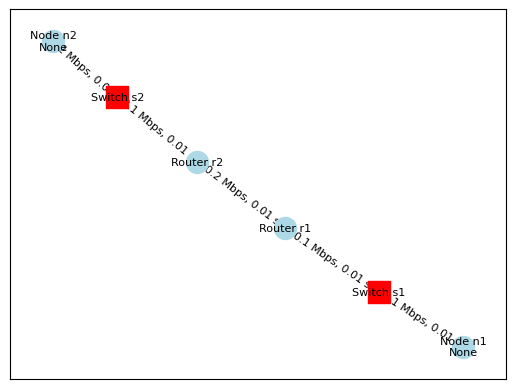

Time: 0.01 Node: r1, Event: dropped BPDU, Packet: 254fff27-fd29-4d21-bf93-2db1e4995946, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: r2, Event: dropped BPDU, Packet: f565431d-16ea-491a-8360-50007c6f8b5f, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: r2, Event: dropped BPDU, Packet: d018dc0b-3f2d-49bb-8843-1377117bc604, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.04284174449859961 Node: s2, Event: received, Packet: 97ceca04-3201-4299-b7b7-9753f461cc90, Src: 192.168.2.254, Dst: 224.0.0.5
Time: 0.09099371986060964 Node: s1, Event: received, Packet: c04df927-e9ab-42be-8525-297bb03e98a7, Src: 192.168.1.254, Dst: 224.0.0.5
Time: 0.3901814984982115 Node: s1, Event: received, Packet: 76814231-a344-4721-ab76-03085a717944, Src: 192.168.1.254/24, Dst: 224.0.0.5
Time: 0.4001814984982115 Node: s2, Event: received, Packet: 335f7e09-33ed-4783-b4d1-e415f2d25610, Src: 10.1.1.1/24, Dst: 224.0.0.5
Time: 0.4247239311141787 Node: s2, Event: received, Packet: c6ed5e70-b0cd-4905-8e76-a098a37d221f, Sr

In [2]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec7a.NetworkEventScheduler import NetworkEventScheduler
from sec7a.Node import Node
from sec7a.Switch import Switch
from sec7a.Router import Router
from sec7a.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.1/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)
# スイッチにも管理用のIPアドレスが設定されることが一般的です（実世界では遠隔ログインなどに利用します）
switch1 = Switch(node_id="s1", ip_address="192.168.1.11/24", network_event_scheduler=nes)
switch2 = Switch(node_id="s2", ip_address="192.168.2.11/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.1.1.1/24"], network_event_scheduler=nes)
router2 = Router(node_id="r2", ip_addresses=["192.168.2.254/24", "10.1.1.2/24"], network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(router1, router2, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(router2, switch2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(switch2, node2, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ノードとルータに宛先IPアドレスとMACアドレスの対応テーブルを設定
node1.add_to_arp_table(node2.ip_address, router1.get_mac_address(link2))
node2.add_to_arp_table(node1.ip_address, router2.get_mac_address(link4))
router1.add_to_arp_table(node1.ip_address,node1.mac_address)
router1.add_to_arp_table(node2.ip_address,router2.get_mac_address(link3))
router2.add_to_arp_table(node1.ip_address,router1.get_mac_address(link3))
router2.add_to_arp_table(node2.ip_address,node2.mac_address)

# ネットワークのトポロジを描画
nes.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_ip="192.168.2.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
switch1.print_forwarding_table()
switch2.print_forwarding_table()

router1.print_interfaces()
router2.print_interfaces()

router1.print_routing_table()
router2.print_routing_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


## カプセル化

### カプセル化とは

パケットにはヘッダが付与されており、アドレス情報等はヘッダに記載されます。
ここまで、単に「ヘッダ」として扱ってきましたが、実際にはレイヤごとにヘッダが定義されます。
これらはMACヘッダ、IPヘッダなどと呼ばれます。
各レイヤに対応したノードや機能は、そのレイヤのヘッダだけにアクセスすれば済むようになっています。
例えば、スイッチはMACアドレスでパケット転送を行うノードですので、MACヘッダにしかアクセスせず、IPヘッダには一切関知しません。
このような機能分離をカプセル化と呼び、パケットは実際にはマトリョーシカのようにヘッダがいくつも付与された構造をしています。

ただしルータは両ヘッダを扱う必要があるため、MACヘッダを扱う機能と、IPヘッダを扱う機能とを分離して備えます。
つまり、受信インタフェースで宛先MACアドレスの照合を行ってMACヘッダを除去し、ルーティング等の処理はIPヘッダの情報を用いて行った上で、パケと転送先に応じて新たにMACヘッダを付与して送出します。

### `Packet`クラスのアップデート

これまで単に`header`として定義されていた情報を、`mac_header`と`ip_header`に分離します。
他のクラスから`packet.header`としてアクセスできるように，MACヘッダとIPヘッダを統合して返すプロパティも準備しておきます。

```
class Packet:
    def __init__(self, source_mac, destination_mac, source_ip, destination_ip, ttl, fragment_flags, fragment_offset, header_size, payload_size, network_event_scheduler):
        
        # MACヘッダ情報を設定
        self.mac_header = {
            "source_mac": source_mac,  # 送信元のMACアドレス
            "destination_mac": destination_mac  # 宛先のMACアドレス
        }
        
        # IPヘッダ情報を設定
        self.ip_header = {
            "source_ip": source_ip,  # 送信元のIPアドレス
            "destination_ip": destination_ip,  # 宛先のIPアドレス
            "ttl": ttl,  # 生存時間（Time To Live）
            "fragment_flags": fragment_flags,  # フラグメントフラグ
            "fragment_offset": fragment_offset  # フラグメントオフセット
        }
   
    @property
    def header(self):
        # MACヘッダとIPヘッダを統合して返すプロパティ（外部からのアクセスに使用）
        return {**self.mac_header, **self.ip_header}
```

さらに以降のルータでの処理に用いるため、MACヘッダを疑似的に除去したり、新たに付与するためのメソッドも定義しておきます。

```
    def remove_mac_header(self):
        # MACヘッダを疑似的に除去するメソッド（MACヘッダ情報を空にする）
        self.mac_header = {}

    def add_mac_header(self, source_mac, destination_mac):
        # 新たな送信元と宛先のMACアドレスを設定してMACヘッダを再付与するメソッド
        self.mac_header = {
            "source_mac": source_mac,
            "destination_mac": destination_mac
        }
```

### `Router`クラスのアップデート

#### パケット受信

パケット受信時には、まずMACアドレスを参照して、自身を宛先としているかを判定します。
つまり当該インタフェースが宛先となっている場合には、パケットを受信します。
このときMACヘッダを除去してから、次のレイヤの処理へと渡すのです。
ここでは以下のように、`packet.remove_mac_header()`により、このステップを模擬しています。

```
    def receive_packet(self, packet, received_link):

            省略

            if packet.header["destination_mac"] == self.get_mac_address(received_link):
                    self.network_event_scheduler.log_packet_info(packet, "received", self.node_id)  # パケット受信をログに記録
                    packet.remove_mac_header()  # MACヘッダを疑似的に除去
                    destination_ip = packet.header["destination_ip"]
                    if '/' in destination_ip:
                        destination_ip, _ = destination_ip.split('/')
                    for link, interface_cidr in self.interfaces.items():
                        network_address, mask_length = interface_cidr.split('/')
                        subnet_mask = self.cidr_to_subnet_mask(mask_length)
                        if self.matches_subnet(destination_ip, network_address, subnet_mask):
                            if self.is_final_destination(packet, network_address):
                                pass
                            else:
                                self.forward_packet(packet)
                            return
                    self.forward_packet(packet)
            else:
                self.network_event_scheduler.log_packet_info(packet, "dropped due to unmatched MAC address", self.node_id)
```

#### パケット転送

ルーティングテーブルを参照し、転送先インタフェースが決まった後には、パケットに新たなMACヘッダを付与してから送出します。
つまり、転送先インタフェースのMACアドレスを送信元MACアドレスとし、次のホップとなるルータのインタフェースないし宛先ノードのMACアドレスを宛先MACアドレスに設定します。
この処理をスマートに実施するために、`process_and_enqueue_packet`メソッドを新たに定義し、`forward_packet`メソッドを以下のように修正します。

```
def forward_packet(self, packet):
    # パケットの宛先IPアドレスを取得
    destination_ip = packet.header["destination_ip"]
    # 宛先IPアドレスに基づいて、次のホップと使用するリンクを取得
    next_hop, link = self.get_route(destination_ip)

    # 宛先IPがマルチキャストアドレスの場合
    if destination_ip == "224.0.0.5":
        # すべてのインターフェースに対してループ処理
        for link in self.interfaces.keys():
            # パケットを処理してキューに追加するメソッドを呼び出し
            self.process_and_enqueue_packet(packet, link)
    # ユニキャストの場合（特定のリンクが見つかった場合）
    elif link:
        # 対象のリンクを使用してパケットを処理してキューに追加
        self.process_and_enqueue_packet(packet, link)
    # デフォルトルートが設定されている場合
    elif self.default_route:
        # デフォルトルートを使用してパケットを処理してキューに追加
        self.process_and_enqueue_packet(packet, self.default_route)
    # 宛先に対するルートが見つからない場合、パケットを破棄
    else:
        # パケット破棄の情報をログに記録
        self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)

def process_and_enqueue_packet(self, packet, link):
    # リンクに基づいて送信元MACアドレスを取得
    source_mac = self.get_mac_address(link)
    # パケットの宛先IPアドレスに基づいて宛先MACアドレスを取得
    destination_mac = self.get_mac_address_from_ip(packet.header["destination_ip"])
    # パケットにMACヘッダを追加（更新）
    packet.add_mac_header(source_mac, destination_mac)
    
    # パケット転送の情報をログに記録
    self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
    
    # 指定されたリンクのキューにパケットを追加
    link.enqueue_packet(packet, self)
```


### カプセル化を適用したシミュレーション

ここまでのアップデートを適用したコードで、シミュレーションを実施してみましょう。
ただしシナリオは以前とまったく同様なので、見た目上、実行結果には差がありません。


fatal: destination path 'network-simulator' already exists and is not an empty directory.


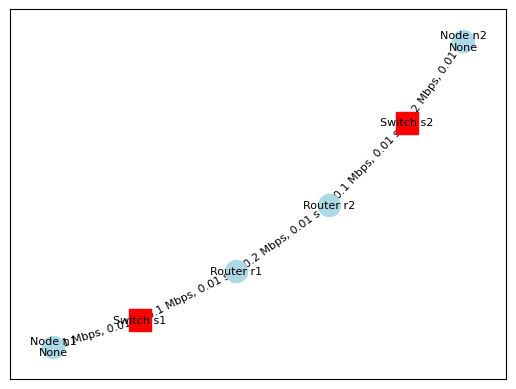

Time: 0.01 Node: r1, Event: dropped BPDU, Packet: 250326ef-c37d-4628-bb30-afc5bbec665b, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: r2, Event: dropped BPDU, Packet: cdbad640-3aa3-46a1-8c51-5bdceb32718f, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: r2, Event: dropped BPDU, Packet: 111cc16c-f21d-47f4-b9b6-0bfc08636afd, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.025795525628240216 Node: s2, Event: received, Packet: dc5a381c-8216-4468-a9f2-470794411693, Src: 192.168.2.254, Dst: 224.0.0.5
Time: 0.060695289819843075 Node: s1, Event: received, Packet: 20a1722c-bc6b-4a4e-8383-a72de90c540f, Src: 192.168.1.254, Dst: 224.0.0.5
Time: 0.4352399153140217 Node: s2, Event: received, Packet: 90f68c70-0c03-4282-9d0f-b8105e4b5c26, Src: 192.168.2.254/24, Dst: 224.0.0.5
Time: 0.4452399153140217 Node: s1, Event: received, Packet: a882d578-bbed-43dd-a1fe-b235db154fdf, Src: 10.1.1.2/24, Dst: 224.0.0.5
Time: 0.4736703956845648 Node: s1, Event: received, Packet: fa043e57-81e3-471e-a5ee-af10201b6440, 

In [3]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec7b.NetworkEventScheduler import NetworkEventScheduler
from sec7b.Node import Node
from sec7b.Switch import Switch
from sec7b.Router import Router
from sec7b.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.1/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.11/24", network_event_scheduler=nes)
switch2 = Switch(node_id="s2", ip_address="192.168.2.11/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.1.1.1/24"], network_event_scheduler=nes)
router2 = Router(node_id="r2", ip_addresses=["192.168.2.254/24", "10.1.1.2/24"], network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(router1, router2, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(router2, switch2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(switch2, node2, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ノードとルータに宛先IPアドレスとMACアドレスの対応テーブルを設定
node1.add_to_arp_table(node2.ip_address, router1.get_mac_address(link2))
node2.add_to_arp_table(node1.ip_address, router2.get_mac_address(link4))
router1.add_to_arp_table(node1.ip_address,node1.mac_address)
router1.add_to_arp_table(node2.ip_address,router2.get_mac_address(link3))
router2.add_to_arp_table(node1.ip_address,router1.get_mac_address(link3))
router2.add_to_arp_table(node2.ip_address,node2.mac_address)

# ネットワークのトポロジを描画
nes.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_ip="192.168.2.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
switch1.print_forwarding_table()
switch2.print_forwarding_table()

router1.print_interfaces()
router2.print_interfaces()

router1.print_routing_table()
router2.print_routing_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


### 演習課題1: ARPテーブルの設定

#### 目的
IPアドレスとMACアドレスの対応関係を表すARPテーブルを設定し、アドレスとレイヤ構造について理解する。

#### 課題の概要
以下のネットワークトポロジにおいて、各ノード・ルータに対してARPテーブルを設定してください。
あらかじめ設定してある通信アプリケーションで、パケットロスなく通信できれば成功です。

```
# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.10.1/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.20.1/24", network_event_scheduler=nes)
node3 = Node(node_id="n3", ip_address="192.168.30.1/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.10.11/24", network_event_scheduler=nes)
switch2 = Switch(node_id="s2", ip_address="192.168.20.11/24", network_event_scheduler=nes)
switch3 = Switch(node_id="s3", ip_address="192.168.30.11/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.10.254/24", "10.1.1.11/24", "10.1.1.12/24"], network_event_scheduler=nes)
router2 = Router(node_id="r2", ip_addresses=["192.168.20.254/24", "10.1.1.21/24", "10.1.1.22/24"], network_event_scheduler=nes)
router3 = Router(node_id="r3", ip_addresses=["192.168.30.254/24", "10.1.1.31/24", "10.1.1.32/24"], network_event_scheduler=nes)

# リンクの設定
link1a = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link1b = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2a = Link(node2, switch2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2b = Link(switch2, router2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3a = Link(node3, switch3, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3b = Link(switch3, router3, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4a = Link(router1, router2, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4b = Link(router2, router3, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4c = Link(router3, router1, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ノードとルータに宛先IPアドレスとMACアドレスの対応テーブルを設定

#
# ここを設定
#

# ネットワークのトポロジを描画
nes.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_ip="192.168.20.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node1.set_traffic(destination_ip="192.168.30.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node2.set_traffic(destination_ip="192.168.10.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node2.set_traffic(destination_ip="192.168.30.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node3.set_traffic(destination_ip="192.168.10.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node3.set_traffic(destination_ip="192.168.20.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

```

### 演習課題2: MACアドレス書き換えの確認

#### 目的
ルータにおけるMACアドレスの書き換え（MACヘッダの付け替え）動作を確認し、カプセル化の概念を理解する。加えて、シミュレータコードのアップデート方法も習得する。

#### 課題
Githubから`Router`クラスのソースコードを取得して、コードセルに貼り付けて実行し、`Router`クラスを再定義します。
そして`Router`クラスをインポートする代わりに（import文を削除あるいはコメントアウトしましょう）、新たに作成したコードブロックを編集することで`Router`クラスを独自にアップデートしてください。

https://github.com/flyby-yunakayama/network-simulator/blob/main/sec7b/Router.py

MACヘッダの付け替えを行っている部分を見つけ、print()文などを用いて、パケットヘッダに対して何が行われているかを出力し確認してください。


## 本章のまとめ

本章では、通信プロトコルのレイヤ構成と、パケットのカプセル化について学習しました。
レイヤ概念の導入によって、ここまでに実装してきたノード、スイッチ、ルータとを相互に接続し、大きなネットワークを模擬できるようになりました。
ノードとスイッチから構成されるローカルネットワークでは、MACアドレスによってパケット転送が行われます。
一方でルータ間ではIPアドレスによってパケットが転送されます。
このようなレイヤを用いることで、レイヤごとの機能がシンプル化され、プロトコルの設計や実装がしやすくなっています。
またMACアドレスを指定せずとも通信ができるようになりました。
ただし、まだIPアドレスとMACアドレスの対応関係を登録する必要があり、これでは不便です。
次章では、この問題を解決するアドレスの問い合わせについて学習します。
